<a href="https://colab.research.google.com/github/VedzKun/ML-Projects/blob/main/ensembleLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# This loads the heart disease dataset reliably
from sklearn.datasets import fetch_openml

heart = fetch_openml(name='heart-statlog', version=1, as_frame=True)

df = heart.frame
print(df.head())

   age  sex  chest  restting_blood_pressure  serum_cholestoral  \
0   70    1      4                     130                322   
1   67    0      3                     115                564   
2   57    1      2                     124                261   
3   64    1      4                     128                263   
4   74    0      2                     120                269   

   fasting_blood_sugar  resting_electrocardiographic_results  \
0                    0                                     2   
1                    0                                     2   
2                    0                                     0   
3                    0                                     0   
4                    0                                     2   

   maximum_heart_rate_achieved  exercise_induced_angina  oldpeak  slope  \
0                          109                        0      2.4      2   
1                          160                        0      1.6      2  

In [4]:
df['class'] = df['class'].map({'present': 1, 'absent': 0})

print("Target distribution:\n", df['class'].value_counts())
print("\nShape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())

Target distribution:
 class
0    150
1    120
Name: count, dtype: int64

Shape: (270, 14)

Missing values:
 age                                     0
sex                                     0
chest                                   0
resting_blood_pressure                  0
serum_cholestoral                       0
fasting_blood_sugar                     0
resting_electrocardiographic_results    0
maximum_heart_rate_achieved             0
exercise_induced_angina                 0
oldpeak                                 0
slope                                   0
number_of_major_vessels                 0
thal                                    0
class                                   0
dtype: int64


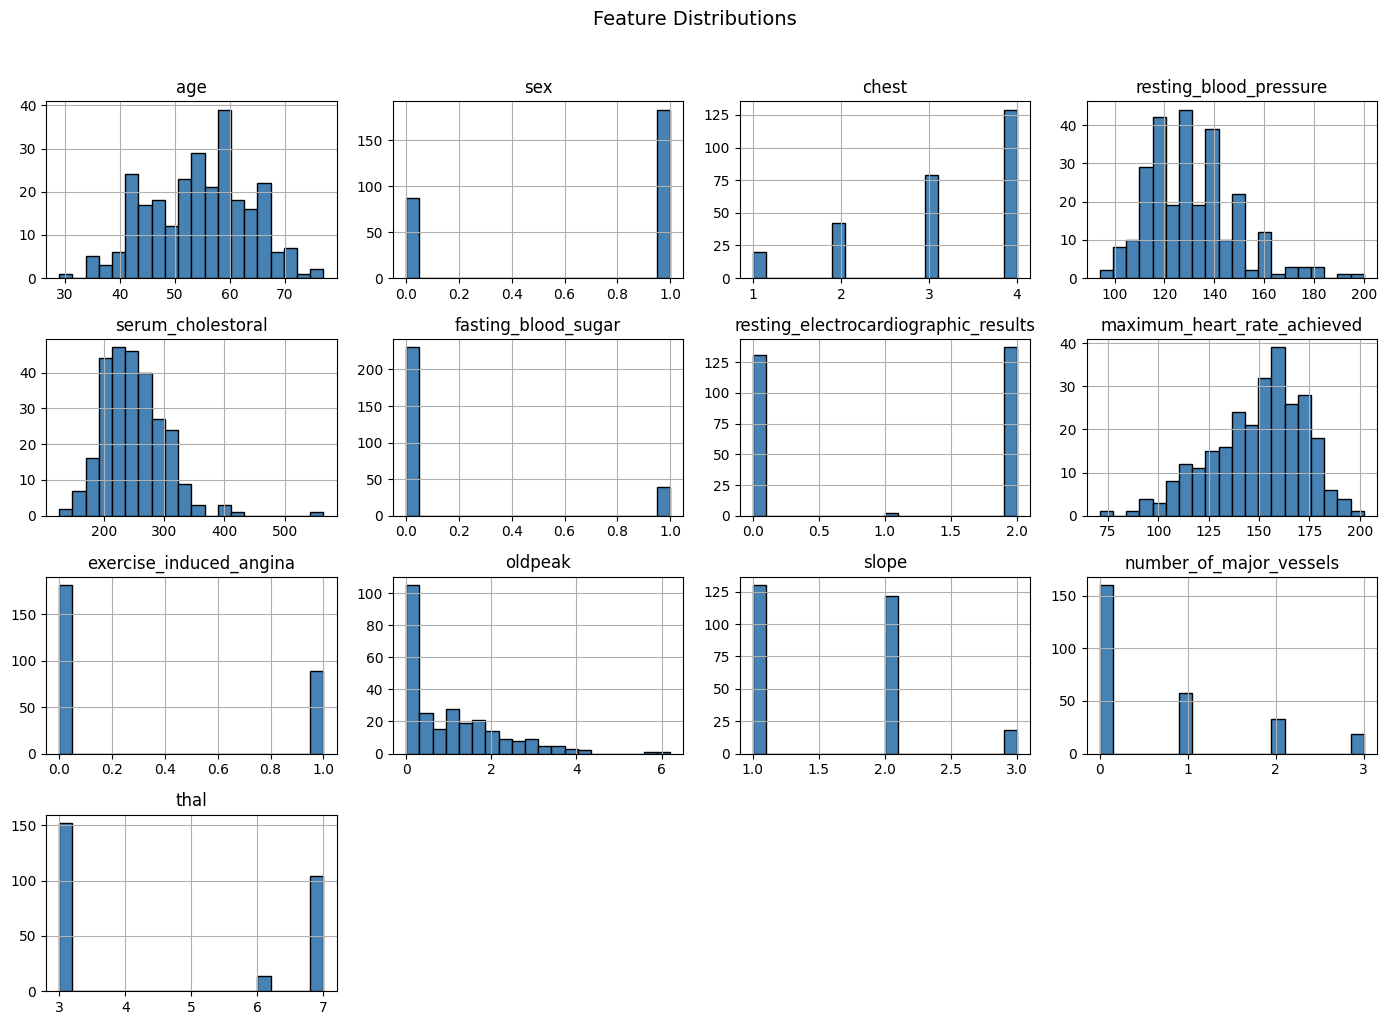

In [5]:
df.hist(figsize=(14, 10), bins=20, color='steelblue', edgecolor='black')
plt.suptitle("Feature Distributions", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

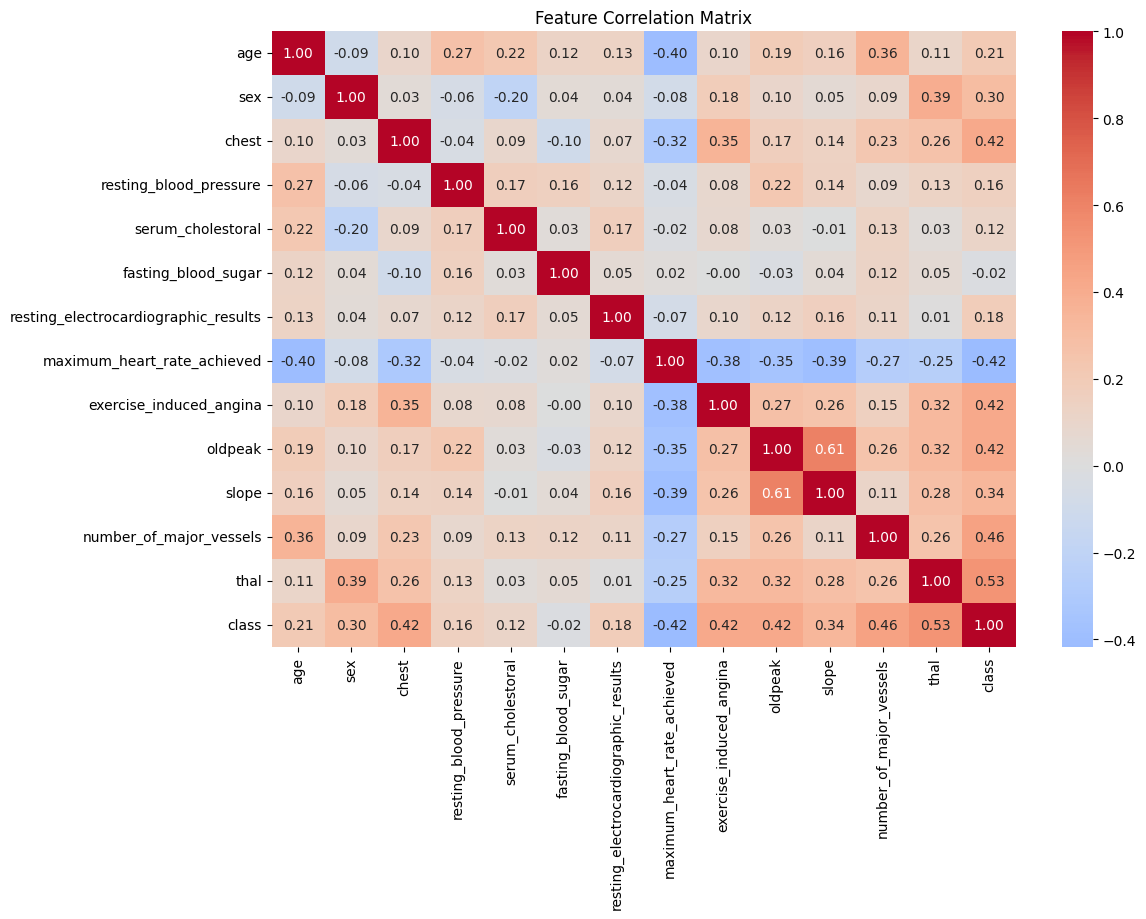

In [6]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

In [7]:
X = df.drop(columns=['class'])   # everything except the target
y = df['class']                  # just the target column

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (270, 13)
Target shape: (270,)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% goes to testing, 80% for training
    random_state=42,      # makes the split reproducible
    stratify=y            # keeps the 0/1 ratio the same in both splits
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (216, 13)
Test set: (54, 13)


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)   # <-- notice: only transform, not fit_transform

print("Sample scaled values:\n", X_train_scaled[:2])

Sample scaled values:
 [[-1.3361797  -1.47528661 -0.10435568 -0.63795169 -0.76298149 -0.39380225
  -1.05474207  1.00746877 -0.68511879 -0.93924147  0.69812296 -0.70900762
  -0.85615942]
 [-0.03903446  0.67783439  0.9202274  -0.52273633  0.73241188 -0.39380225
   0.95252037 -1.5511029   1.4596009   1.93715953  0.69812296  1.43288953
  -0.85615942]]


In [10]:
# Confirm scaling worked — mean should be ~0, std should be ~1
print("Mean of scaled training features (should be ~0):")
print(X_train_scaled.mean(axis=0).round(2))

print("\nStd of scaled training features (should be ~1):")
print(X_train_scaled.std(axis=0).round(2))

Mean of scaled training features (should be ~0):
[-0. -0.  0. -0. -0. -0.  0.  0.  0.  0. -0. -0.  0.]

Std of scaled training features (should be ~1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [11]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42, max_iter=1000)

# Train on the SCALED training data
lr_model.fit(X_train_scaled, y_train)

print("Model trained!")

Model trained!


In [12]:
# Predict on the test set
y_pred = lr_model.predict(X_test_scaled)

# Also get probabilities (useful later)
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]  # probability of class 1

print("First 10 predictions:", y_pred[:10])
print("First 10 actual:     ", y_test.values[:10])

First 10 predictions: [0 0 0 1 0 0 0 1 1 1]
First 10 actual:      [0, 0, 0, 1, 0, 0, 0, 1, 1, 1]
Categories (2, int64): [0, 1]


In [13]:
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score, confusion_matrix)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")

Accuracy  : 0.8519
Precision : 0.7857
Recall    : 0.9167
F1 Score  : 0.8462


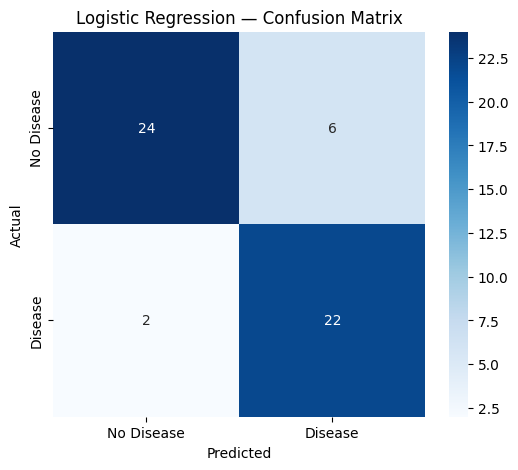

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Logistic Regression — Confusion Matrix')
plt.show()

/tmp/ipykernel_8872/3159685182.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='coolwarm')


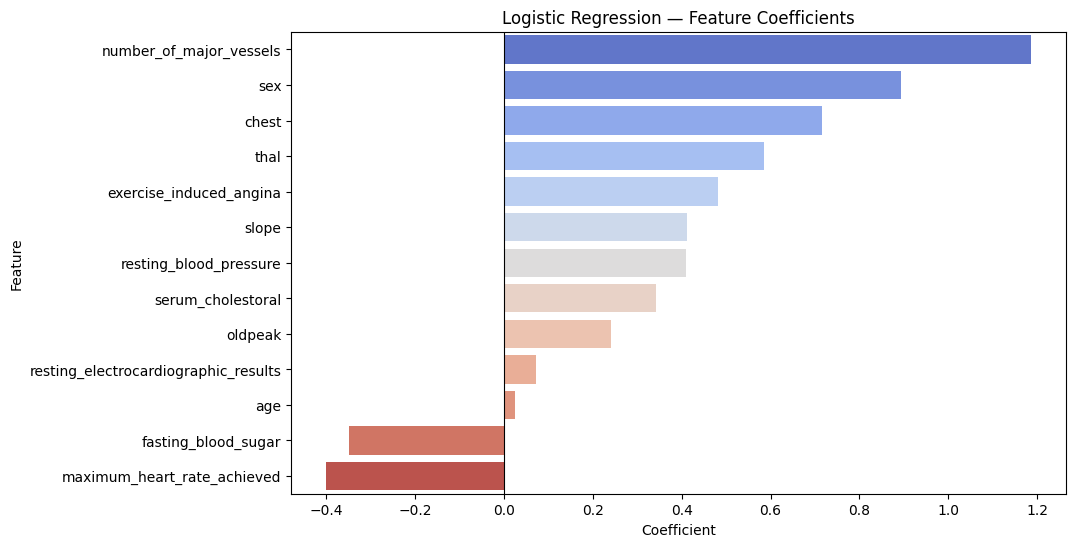

In [15]:
feature_names = X.columns
coefficients = lr_model.coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='coolwarm')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression — Feature Coefficients')
plt.show()

In [16]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)  # no max_depth limit yet

# Decision trees don't need scaled data — use raw splits
dt_model.fit(X_train, y_train)

print("Training Accuracy  :", dt_model.score(X_train, y_train))
print("Test Accuracy      :", dt_model.score(X_test, y_test))

Training Accuracy  : 1.0
Test Accuracy      : 0.7962962962962963


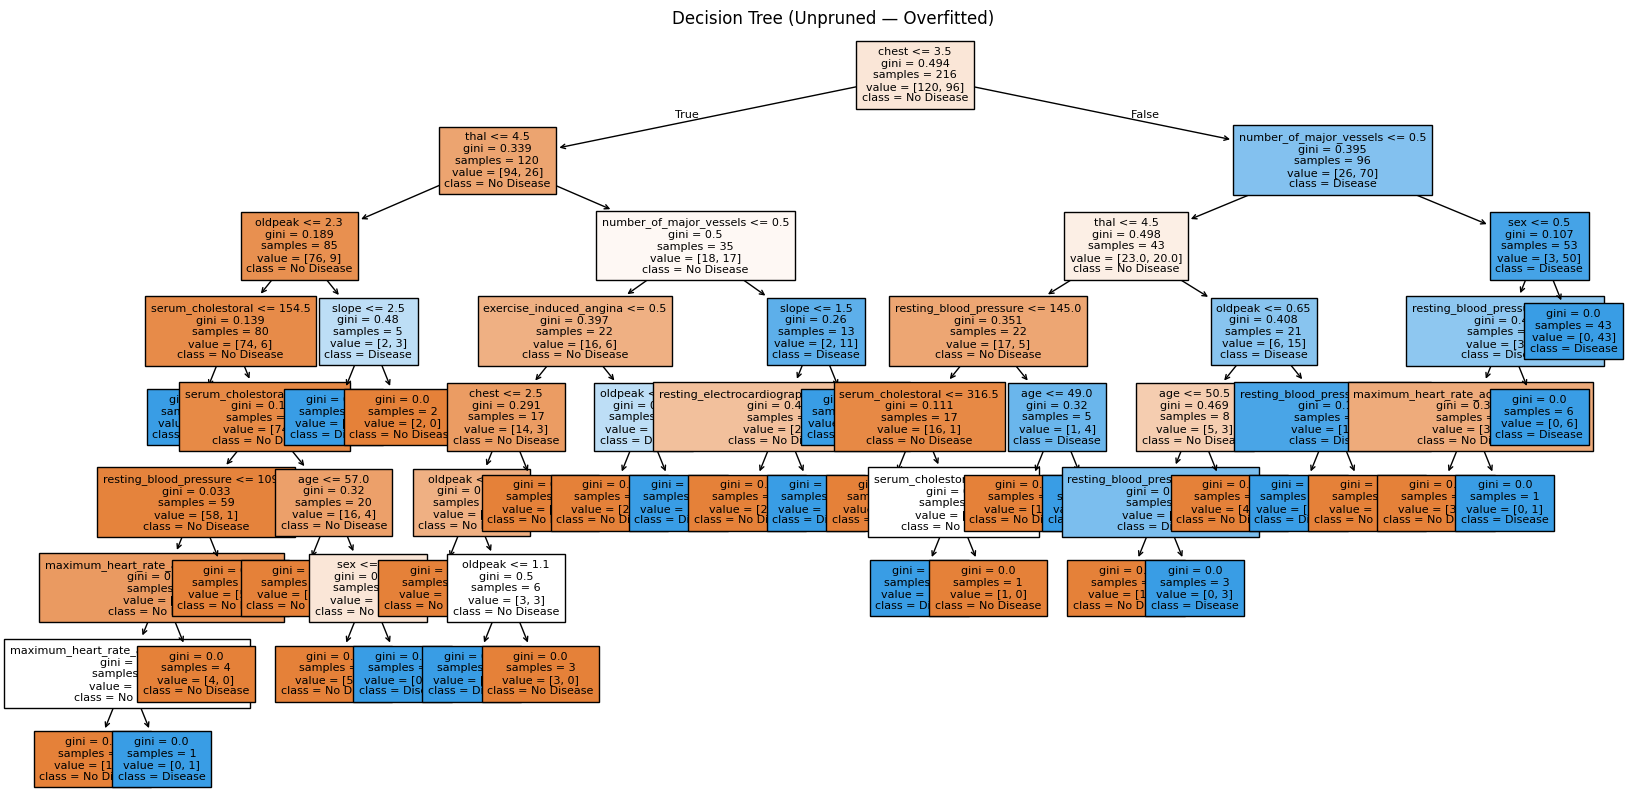

In [17]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dt_model,
          feature_names=X.columns,
          class_names=['No Disease', 'Disease'],
          filled=True,
          fontsize=8)
plt.title("Decision Tree (Unpruned — Overfitted)")
plt.show()

In [18]:
# max_depth limits how deep the tree can grow
dt_pruned = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_pruned.fit(X_train, y_train)

print("Training Accuracy  :", dt_pruned.score(X_train, y_train))
print("Test Accuracy      :", dt_pruned.score(X_test, y_test))

Training Accuracy  : 0.9166666666666666
Test Accuracy      : 0.7962962962962963


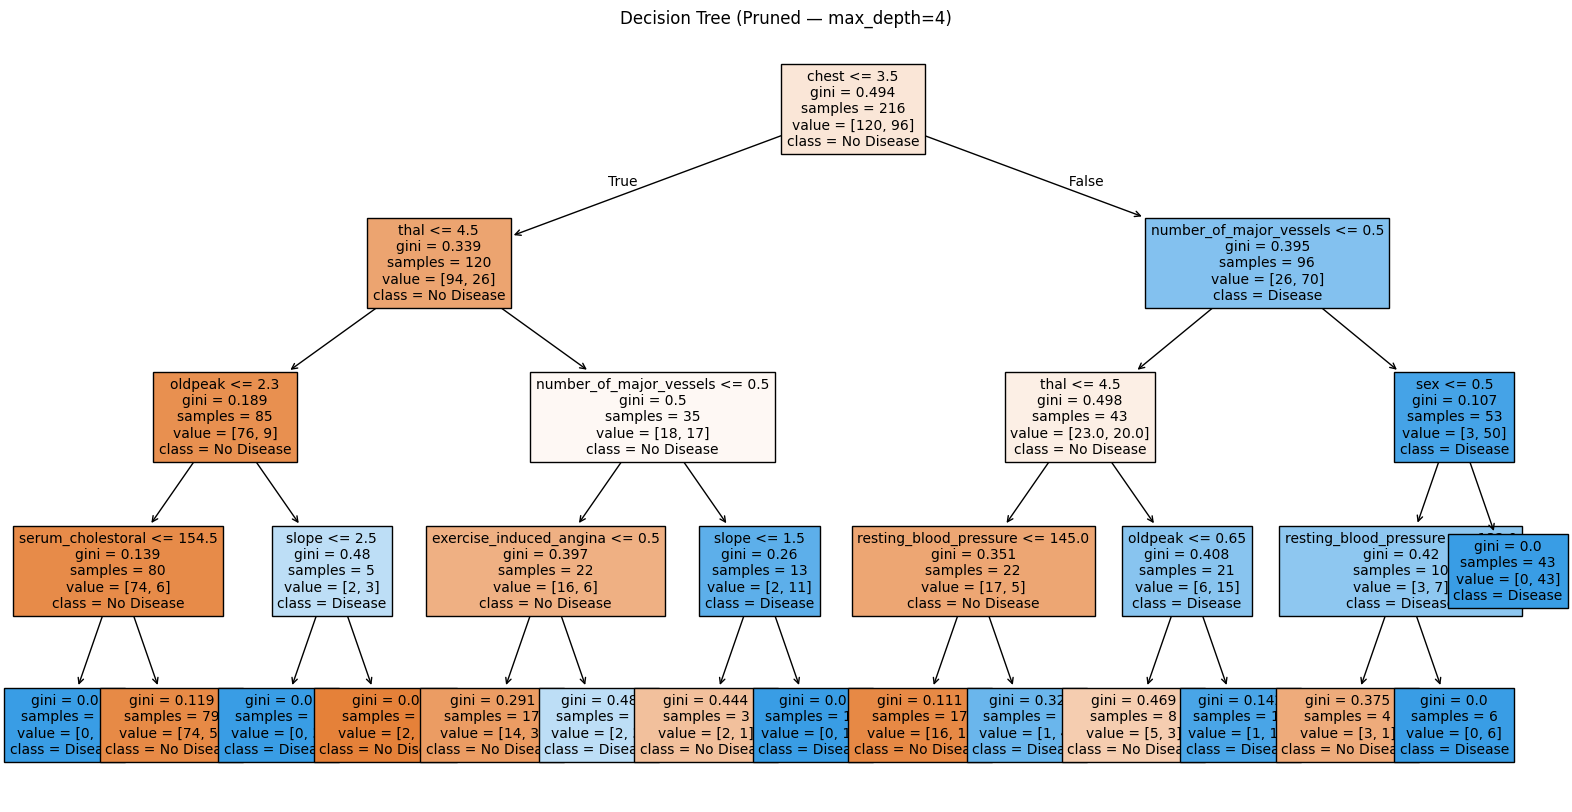

In [19]:
plt.figure(figsize=(20, 10))
plot_tree(dt_pruned,
          feature_names=X.columns,
          class_names=['No Disease', 'Disease'],
          filled=True,
          fontsize=10)
plt.title("Decision Tree (Pruned — max_depth=4)")
plt.show()


In [20]:
from sklearn.metrics import f1_score, classification_report

y_pred_dt = dt_pruned.predict(X_test)

print(classification_report(y_test, y_pred_dt, target_names=['No Disease', 'Disease']))


              precision    recall  f1-score   support

  No Disease       0.85      0.77      0.81        30
     Disease       0.74      0.83      0.78        24

    accuracy                           0.80        54
   macro avg       0.80      0.80      0.80        54
weighted avg       0.80      0.80      0.80        54



/tmp/ipykernel_8872/3260544845.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


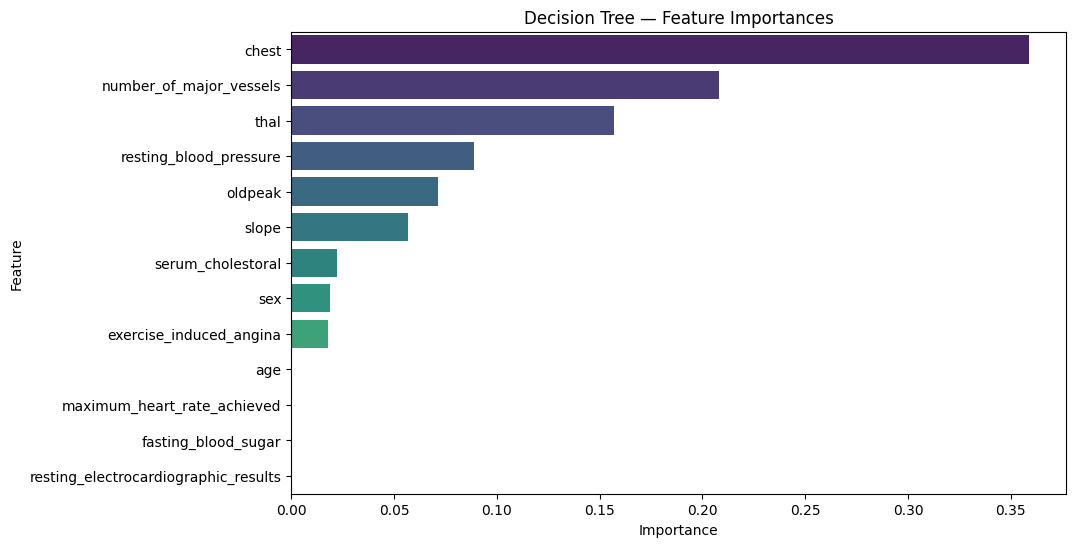

In [21]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_pruned.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title("Decision Tree — Feature Importances")
plt.show()

In [22]:
from sklearn.metrics import f1_score

results = {
    'Logistic Regression': f1_score(y_test, lr_model.predict(X_test_scaled)),
    'Decision Tree (pruned)': f1_score(y_test, dt_pruned.predict(X_test)),
}

for model, score in results.items():
    print(f"{model:30s} F1: {score:.4f}")

Logistic Regression            F1: 0.8462
Decision Tree (pruned)         F1: 0.7843


In [23]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline

# StratifiedKFold preserves class ratio in every fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Pipeline bundles scaler + model so scaling happens correctly inside each fold
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])

lr_scores = cross_val_score(lr_pipeline, X, y, cv=cv, scoring='f1')

print("LR F1 per fold :", lr_scores.round(4))
print("LR Mean F1     :", lr_scores.mean().round(4))
print("LR Std Dev     :", lr_scores.std().round(4))

LR F1 per fold : [0.8571 0.875  0.7273 0.7273 0.8571]
LR Mean F1     : 0.8088
LR Std Dev     : 0.0669


In [24]:
# Decision tree doesn't need scaling so no pipeline needed
dt_scores = cross_val_score(
    DecisionTreeClassifier(max_depth=4, random_state=42),
    X, y, cv=cv, scoring='f1'
)

print("DT F1 per fold :", dt_scores.round(4))
print("DT Mean F1     :", dt_scores.mean().round(4))
print("DT Std Dev     :", dt_scores.std().round(4))

DT F1 per fold : [0.6829 0.7442 0.5    0.6957 0.8085]
DT Mean F1     : 0.6863
DT Std Dev     : 0.103


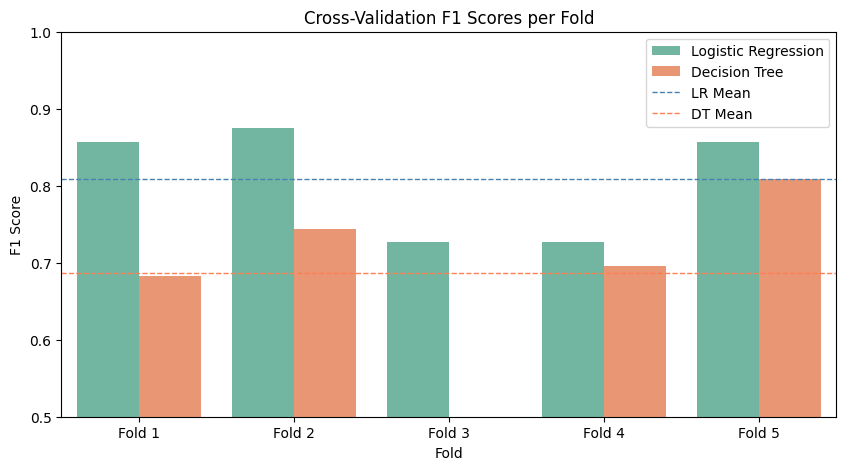

In [25]:
fold_df = pd.DataFrame({
    'Fold': [f'Fold {i+1}' for i in range(5)] * 2,
    'F1 Score': list(lr_scores) + list(dt_scores),
    'Model': ['Logistic Regression'] * 5 + ['Decision Tree'] * 5
})

plt.figure(figsize=(10, 5))
sns.barplot(x='Fold', y='F1 Score', hue='Model', data=fold_df, palette='Set2')
plt.axhline(lr_scores.mean(), color='steelblue', linestyle='--', linewidth=1, label='LR Mean')
plt.axhline(dt_scores.mean(), color='coral', linestyle='--', linewidth=1, label='DT Mean')
plt.ylim(0.5, 1.0)
plt.title("Cross-Validation F1 Scores per Fold")
plt.legend()
plt.show()

In [26]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 7, None],
    'min_samples_split': [2, 5, 10],  # min samples needed to split a node
    'min_samples_leaf': [1, 2, 4]     # min samples required at a leaf node
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1   # use all CPU cores
)

grid_search.fit(X, y)

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1     :", grid_search.best_score_.round(4))

Best Parameters: {'max_depth': 6, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best CV F1     : 0.7336


In [27]:
best_dt = grid_search.best_estimator_

cv_results = {
    'Logistic Regression': lr_scores.mean(),
    'Decision Tree (tuned)': grid_search.best_score_,
}

for model, score in cv_results.items():
    print(f"{model:30s} CV F1: {score:.4f}")

Logistic Regression            CV F1: 0.8088
Decision Tree (tuned)          CV F1: 0.7336


In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,   # number of trees
    random_state=42,
    n_jobs=-1           # use all cores
)

rf_model.fit(X_train, y_train)

print("Training Accuracy:", rf_model.score(X_train, y_train))
print("Test Accuracy    :", rf_model.score(X_test, y_test))

Training Accuracy: 1.0
Test Accuracy    : 0.8148148148148148


In [29]:
rf_scores = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X, y, cv=cv, scoring='f1'
)

print("RF F1 per fold :", rf_scores.round(4))
print("RF Mean F1     :", rf_scores.mean().round(4))
print("RF Std Dev     :", rf_scores.std().round(4))

RF F1 per fold : [0.75   0.8889 0.64   0.7111 0.8889]
RF Mean F1     : 0.7758
RF Std Dev     : 0.0989


In [30]:
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [4, 6, 8, None],
    'max_features': ['sqrt', 'log2'],   # how many features to consider at each split
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

rf_grid.fit(X, y)

print("Best Parameters:", rf_grid.best_params_)
print("Best CV F1     :", rf_grid.best_score_.round(4))

Best Parameters: {'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'n_estimators': 200}
Best CV F1     : 0.8024


/tmp/ipykernel_8872/4264476799.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


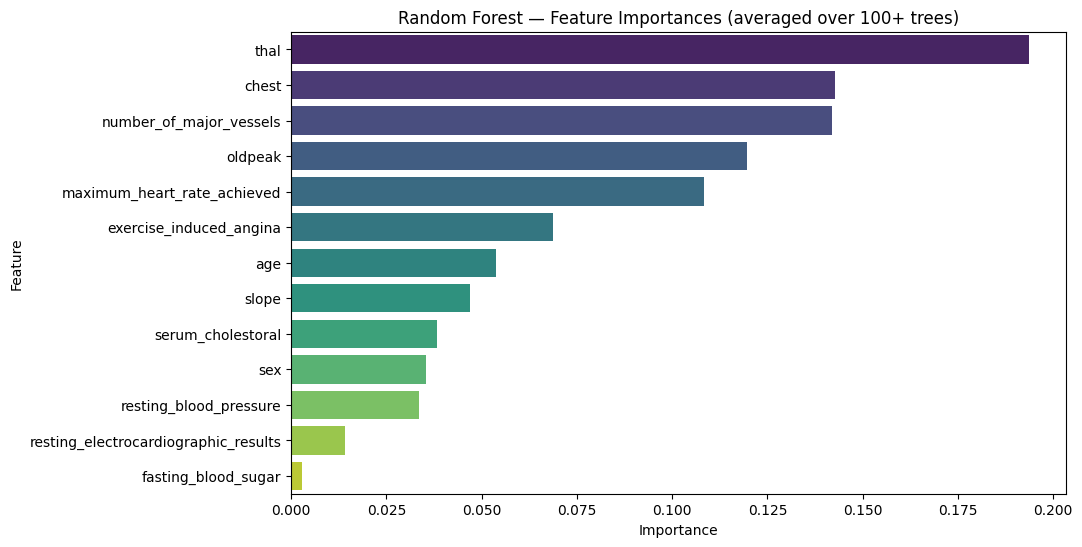

In [32]:
best_rf = rf_grid.best_estimator_

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title("Random Forest — Feature Importances (averaged over 100+ trees)")
plt.show()

/tmp/ipykernel_8872/4264476799.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


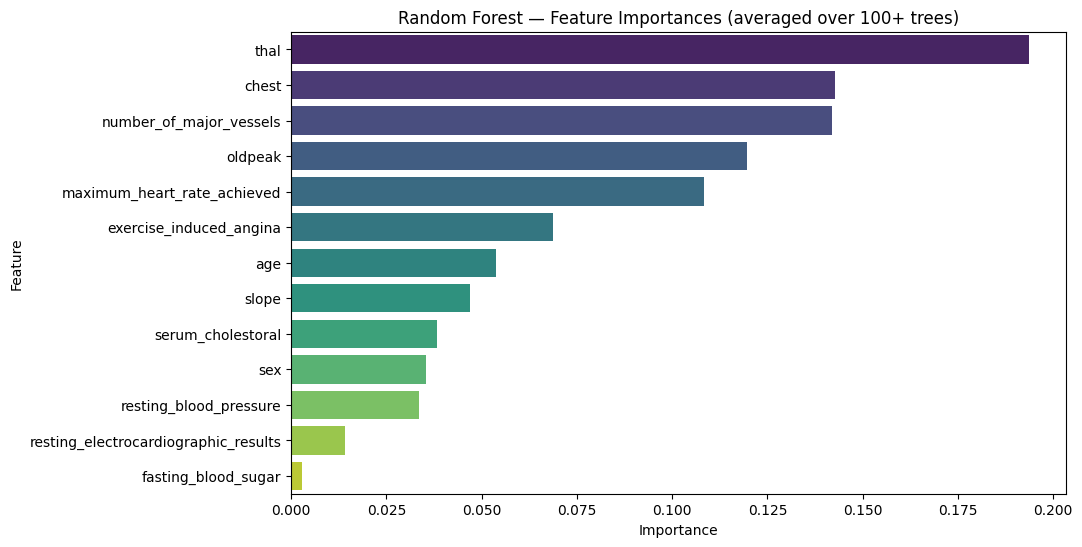

In [33]:
best_rf = rf_grid.best_estimator_

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title("Random Forest — Feature Importances (averaged over 100+ trees)")
plt.show()

In [34]:
!pip install xgboost -q

import xgboost as xgb
print("XGBoost version:", xgb.__version__)

XGBoost version: 3.2.0


In [35]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,      # how much each tree corrects the previous
    max_depth=4,
    random_state=42,
    eval_metric='logloss',  # suppresses a warning
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

print("Training Accuracy:", xgb_model.score(X_train, y_train))
print("Test Accuracy    :", xgb_model.score(X_test, y_test))

Training Accuracy: 1.0
Test Accuracy    : 0.8333333333333334


In [36]:
xgb_scores = cross_val_score(
    XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=4,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    ),
    X, y, cv=cv, scoring='f1'
)

print("XGB F1 per fold:", xgb_scores.round(4))
print("XGB Mean F1    :", xgb_scores.mean().round(4))
print("XGB Std Dev    :", xgb_scores.std().round(4))

XGB F1 per fold: [0.766  0.875  0.7308 0.6829 0.8444]
XGB Mean F1    : 0.7798
XGB Std Dev    : 0.071


In [38]:
xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]         # fraction of rows used per tree
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
    xgb_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

xgb_grid.fit(X, y)

print("Best Parameters:", xgb_grid.best_params_)
print("Best CV F1     :", xgb_grid.best_score_.round(4))

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50, 'subsample': 0.8}
Best CV F1     : 0.7932


In [39]:
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import Pipeline

# Rebuild best versions of each model
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])

dt_best = DecisionTreeClassifier(
    **{k: v for k, v in grid_search.best_params_.items()},
    random_state=42
)

rf_best = rf_grid.best_estimator_
xgb_best = xgb_grid.best_estimator_

# Voting classifier — combines all four
voting_clf = VotingClassifier(
    estimators=[
        ('lr', lr_pipe),
        ('dt', dt_best),
        ('rf', rf_best),
        ('xgb', xgb_best)
    ],
    voting='soft'   # uses predicted probabilities, not just hard yes/no votes
)

voting_scores = cross_val_score(voting_clf, X, y, cv=cv, scoring='f1', n_jobs=-1)

print("Voting F1 per fold:", voting_scores.round(4))
print("Voting Mean F1    :", voting_scores.mean().round(4))
print("Voting Std Dev    :", voting_scores.std().round(4))

Voting F1 per fold: [0.7391 0.8936 0.6923 0.7273 0.8696]
Voting Mean F1    : 0.7844
Voting Std Dev    : 0.0812


/tmp/ipykernel_8872/939372060.py:24: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


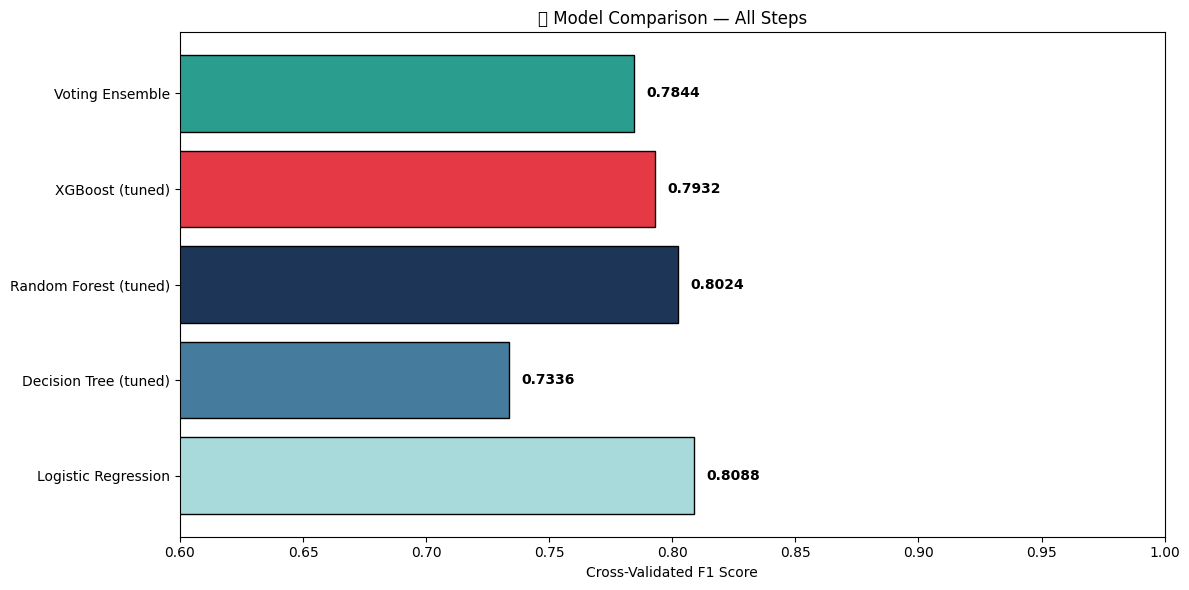

In [40]:
cv_results = {
    'Logistic Regression'  : lr_scores.mean(),
    'Decision Tree (tuned)': grid_search.best_score_,
    'Random Forest (tuned)': rf_grid.best_score_,
    'XGBoost (tuned)'      : xgb_grid.best_score_,
    'Voting Ensemble'      : voting_scores.mean(),
}

models = list(cv_results.keys())
scores = list(cv_results.values())
colors = ['#a8dadc', '#457b9d', '#1d3557', '#e63946', '#2a9d8f']

plt.figure(figsize=(12, 6))
bars = plt.barh(models, scores, color=colors, edgecolor='black')
plt.xlim(0.6, 1.0)
plt.xlabel("Cross-Validated F1 Score")
plt.title("🏆 Model Comparison — All Steps")

# Add score labels on bars
for bar, score in zip(bars, scores):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{score:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

=== Final Model: Voting Ensemble ===

              precision    recall  f1-score   support

  No Disease       0.89      0.80      0.84        30
     Disease       0.78      0.88      0.82        24

    accuracy                           0.83        54
   macro avg       0.83      0.84      0.83        54
weighted avg       0.84      0.83      0.83        54



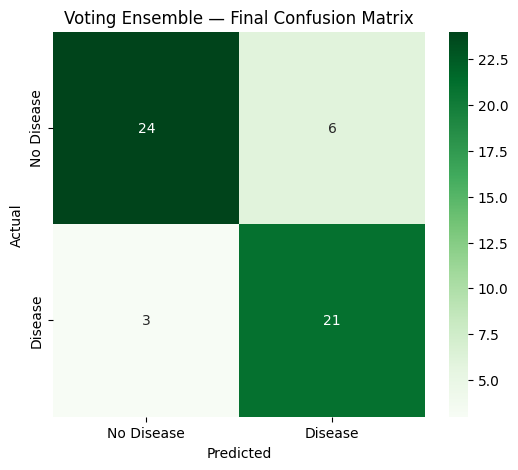

In [41]:
from sklearn.metrics import classification_report, confusion_matrix

# Fit voting classifier on full training set
voting_clf.fit(X_train, y_train)
y_pred_final = voting_clf.predict(X_test)

print("=== Final Model: Voting Ensemble ===\n")
print(classification_report(y_test, y_pred_final,
      target_names=['No Disease', 'Disease']))

cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Voting Ensemble — Final Confusion Matrix')
plt.show()

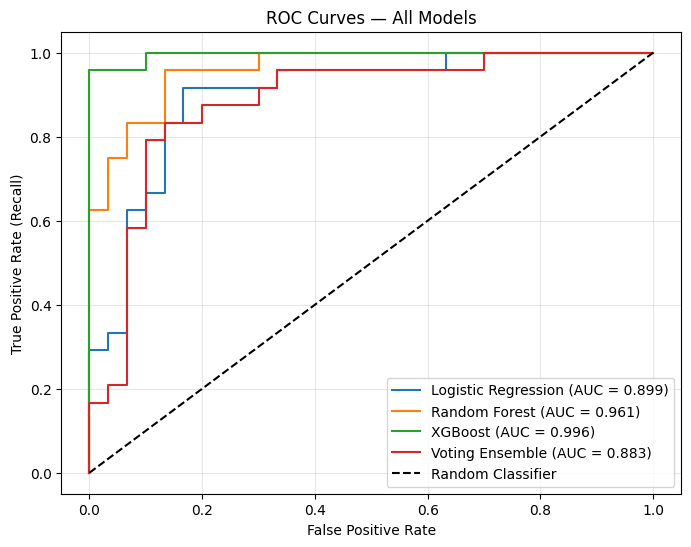

In [42]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8, 6))

model_dict = {
    'Logistic Regression': (lr_pipeline, X_test, True),
    'Random Forest'       : (rf_best, X_test, False),
    'XGBoost'             : (xgb_best, X_test, False),
    'Voting Ensemble'     : (voting_clf, X_test, False),
}

for name, (model, X_eval, needs_scale) in model_dict.items():
    if needs_scale:
        model.fit(X_train, y_train)
        probs = model.predict_proba(X_eval)[:, 1]
    else:
        probs = model.predict_proba(X_eval)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curves — All Models")
plt.legend()
plt.grid(alpha=0.3)
plt.show()